## Bước 1: Đọc dữ liệu Top 20 Association Rules

Bước này đọc file chứa 20 luật kết hợp mạnh nhất đã được tạo ở bước Association Rules.

Input:
- top_20_association_rules.csv

Output:
- top20_rules

Dữ liệu này sẽ được sử dụng cho toàn bộ các biểu đồ trong phần trực quan hóa.

In [ ]:
# Import các thư viện cần thiết
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Cài đặt style mặc định cho biểu đồ
sns.set_theme(style="whitegrid")

# Đọc file top 20 association rules
top20_rules = pd.read_csv("top_20_association_rules.csv")

# Reset index để dễ xử lý
top20_rules = top20_rules.reset_index(drop=True)

# Tạo mã số cho từng rule
top20_rules["rule_id"] = range(1, len(top20_rules) + 1)

# Kiểm tra dữ liệu
print("Shape:", top20_rules.shape)

top20_rules.head(20)

Shape: (20, 18)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedents_str,consequents_str,rule,rule_id
0,"frozenset({'22748', '22745'})",frozenset({'22746'}),0.014077,0.014077,0.010433,0.741107,52.646405,1.0,0.010234,3.808221,0.995012,0.588697,0.737410,0.741107,"22748, 22745",22746,"22748, 22745 → 22746",1
1,frozenset({'22746'}),"frozenset({'22748', '22745'})",0.014077,0.014077,0.010433,0.741107,52.646405,1.0,0.010234,3.808221,0.995012,0.588697,0.737410,0.741107,22746,"22748, 22745","22746 → 22748, 22745",2
2,"frozenset({'22748', '22746'})",frozenset({'22745'}),0.011991,0.017193,0.010433,0.870070,50.606233,1.0,0.010226,7.564104,0.992136,0.556380,0.867797,0.738433,"22748, 22746",22745,"22748, 22746 → 22745",3
3,frozenset({'22745'}),"frozenset({'22748', '22746'})",0.017193,0.011991,0.010433,0.606796,50.606233,1.0,0.010226,2.512715,0.997388,0.556380,0.602024,0.738433,22745,"22748, 22746","22745 → 22748, 22746",4
4,frozenset({'22300'}),frozenset({'22301'}),0.013131,0.015635,0.010015,0.762712,48.782345,1.0,0.009810,4.148395,0.992534,0.534125,0.758943,0.701641,22300,22301,22300 → 22301,5
5,frozenset({'22301'}),frozenset({'22300'}),0.015635,0.013131,0.010015,0.640569,48.782345,1.0,0.009810,2.745645,0.995059,0.534125,0.635787,0.701641,22301,22300,22301 → 22300,6
6,"frozenset({'22746', '22745'})",frozenset({'22748'}),0.011601,0.018473,0.010433,0.899281,48.681687,1.0,0.010218,9.745164,0.990955,0.531161,0.897385,0.732020,"22746, 22745",22748,"22746, 22745 → 22748",7
7,frozenset({'22748'}),"frozenset({'22746', '22745'})",0.018473,0.011601,0.010433,0.564759,48.681687,1.0,0.010218,2.270924,0.997892,0.531161,0.559651,0.732020,22748,"22746, 22745","22748 → 22746, 22745",8
8,frozenset({'22746'}),frozenset({'22745'}),0.014077,0.017193,0.011601,0.824111,47.933104,1.0,0.011359,5.587645,0.993118,0.589816,0.821034,0.749434,22746,22745,22746 → 22745,9
9,frozenset({'22745'}),frozenset({'22746'}),0.017193,0.014077,0.011601,0.674757,47.933104,1.0,0.011359,3.031345,0.996266,0.589816,0.670113,0.749434,22745,22746,22745 → 22746,10


## Bước 2: Vẽ Network Graph Item Associations

Bước này vẽ mạng lưới liên kết giữa các item xuất hiện trong top 20 association rules.

Các rule hai chiều hoặc rule bị lặp sẽ được gom lại thành một liên kết duy nhất giữa các item.

Ý nghĩa:

- Node biểu diễn từng item.
- Edge biểu diễn hai item có quan hệ association.
- Biểu đồ không thể hiện hướng của rule.
- Biểu đồ chỉ tập trung vào việc item nào được liên kết với item nào.

Number of nodes: 10
Number of edges: 7


C:\Users\acer\AppData\Local\Temp\ipykernel_16632\4104274712.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


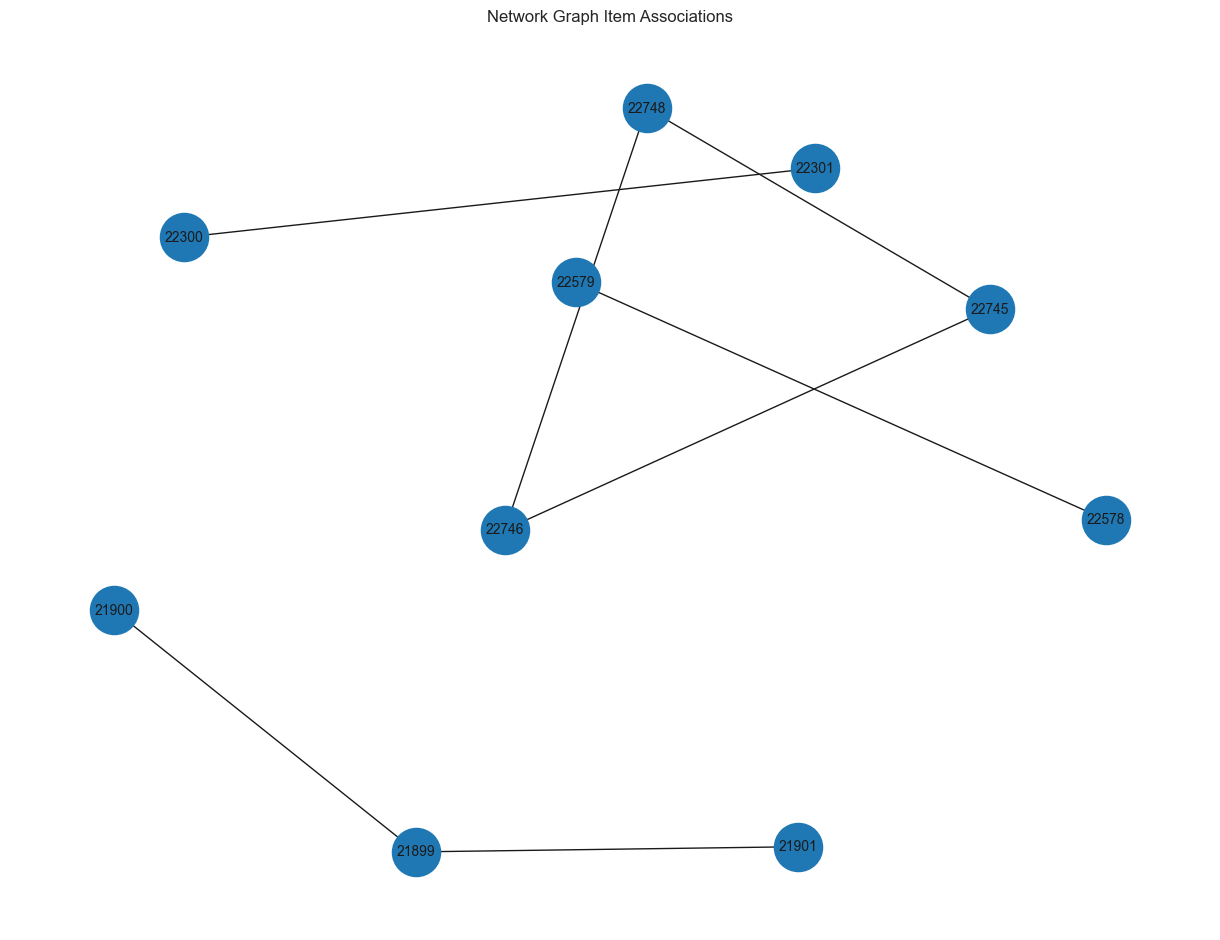

In [ ]:
# Tạo graph không hướng vì chỉ muốn nối các item có liên quan
item_graph = nx.Graph()

# Duyệt qua từng rule trong top 20 rules
for _, row in top20_rules.iterrows():

    # Tách item ở antecedents và consequents
    antecedent_items = str(row["antecedents_str"]).split(", ")
    consequent_items = str(row["consequents_str"]).split(", ")

    # Gom tất cả item trong cùng một rule
    all_items = antecedent_items + consequent_items

    # Tạo cạnh giữa tất cả các cặp item trong cùng rule
    for i in range(len(all_items)):
        for j in range(i + 1, len(all_items)):

            item_1 = all_items[i]
            item_2 = all_items[j]

            # Bỏ qua nếu hai item giống nhau
            if item_1 != item_2:
                item_graph.add_edge(item_1, item_2)

# Kiểm tra số node và edge
print("Number of nodes:", item_graph.number_of_nodes())
print("Number of edges:", item_graph.number_of_edges())

# Tạo figure
plt.figure(figsize=(12, 9))

# Tạo layout, tăng k để dây dài hơn và node cách xa nhau hơn
position = nx.spring_layout(
    item_graph,
    seed=42,
    k=1.5
)

# Vẽ graph đơn giản
nx.draw(
    item_graph,
    position,
    with_labels=True,
    node_size=1200,
    font_size=10
)

# Đặt tiêu đề
plt.title("Network Graph Item Associations")

# Tắt trục tọa độ
plt.axis("off")

# Tối ưu bố cục
plt.tight_layout()

# Lưu hình
plt.savefig(
    "network_graph_item_associations.png",
    dpi=300,
    bbox_inches="tight"
)

# Hiển thị biểu đồ
plt.show()

## Bước 3: Vẽ Scatter Plot giữa Lift và Confidence

Bước này vẽ biểu đồ scatter để quan sát mối quan hệ giữa hai chỉ số quan trọng của association rules:

- Confidence
- Lift

Ý nghĩa:

- Trục X biểu diễn confidence.
- Trục Y biểu diễn lift.
- Mỗi điểm biểu diễn một association rule trong top 20 rules.
- Những điểm nằm cao hơn có lift lớn hơn, tức là mối quan hệ giữa các item mạnh hơn.
- Những điểm nằm bên phải có confidence cao hơn, tức là xác suất mua consequent khi đã mua antecedent cao hơn.

Biểu đồ này giúp đánh giá chất lượng của các rule dựa trên cả lift và confidence.

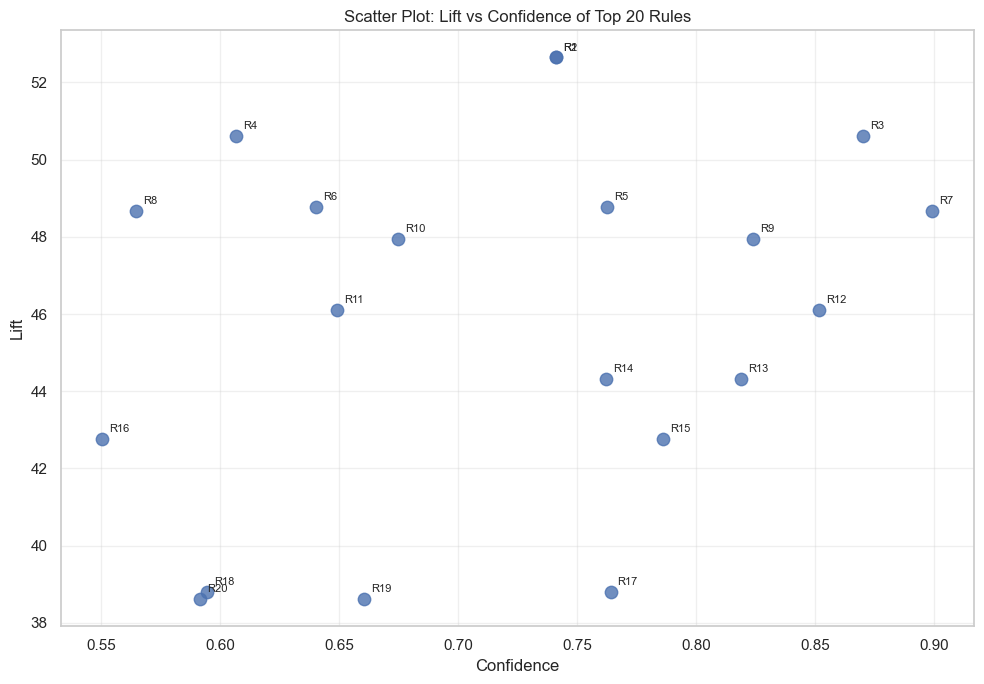

In [ ]:
# Tạo figure
plt.figure(figsize=(10, 7))

# Vẽ scatter plot giữa confidence và lift
plt.scatter(
    top20_rules["confidence"],
    top20_rules["lift"],
    s=80,
    alpha=0.8
)

# Gắn rule_id cho từng điểm để dễ đối chiếu với bảng rule
for _, row in top20_rules.iterrows():
    plt.annotate(
        f"R{row['rule_id']}",
        (
            row["confidence"],
            row["lift"]
        ),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points"
    )

# Đặt tên trục X
plt.xlabel("Confidence")

# Đặt tên trục Y
plt.ylabel("Lift")

# Đặt tiêu đề
plt.title("Scatter Plot: Lift vs Confidence of Top 20 Rules")

# Thêm grid
plt.grid(True, alpha=0.3)

# Tối ưu bố cục
plt.tight_layout()

# Lưu hình
plt.savefig(
    "scatter_lift_vs_confidence_top20.png",
    dpi=300,
    bbox_inches="tight"
)

# Hiển thị biểu đồ
plt.show()

In [ ]:
# Bảng đối chiếu rule_id với rule
top20_rules[
    ["rule_id", "rule", "support", "confidence", "lift"]
]

,rule_id,rule,support,confidence,lift
0,1,"22748, 22745 → 22746",0.010433,0.741107,52.646405
1,2,"22746 → 22748, 22745",0.010433,0.741107,52.646405
2,3,"22748, 22746 → 22745",0.010433,0.870070,50.606233
3,4,"22745 → 22748, 22746",0.010433,0.606796,50.606233
4,5,22300 → 22301,0.010015,0.762712,48.782345
5,6,22301 → 22300,0.010015,0.640569,48.782345
6,7,"22746, 22745 → 22748",0.010433,0.899281,48.681687
7,8,"22748 → 22746, 22745",0.010433,0.564759,48.681687
8,9,22746 → 22745,0.011601,0.824111,47.933104
9,10,22745 → 22746,0.011601,0.674757,47.933104


## Bước 4: Vẽ Bar Chart Top Rules

Bước này vẽ biểu đồ cột ngang để xếp hạng 20 association rules theo giá trị lift.

Ý nghĩa:

- Mỗi thanh biểu diễn một association rule.
- Chiều dài thanh biểu diễn giá trị lift.
- Rule có lift càng cao thì mối quan hệ giữa antecedent và consequent càng mạnh.
- Biểu đồ này giúp xác định nhanh các rule có tiềm năng cross-selling tốt nhất.

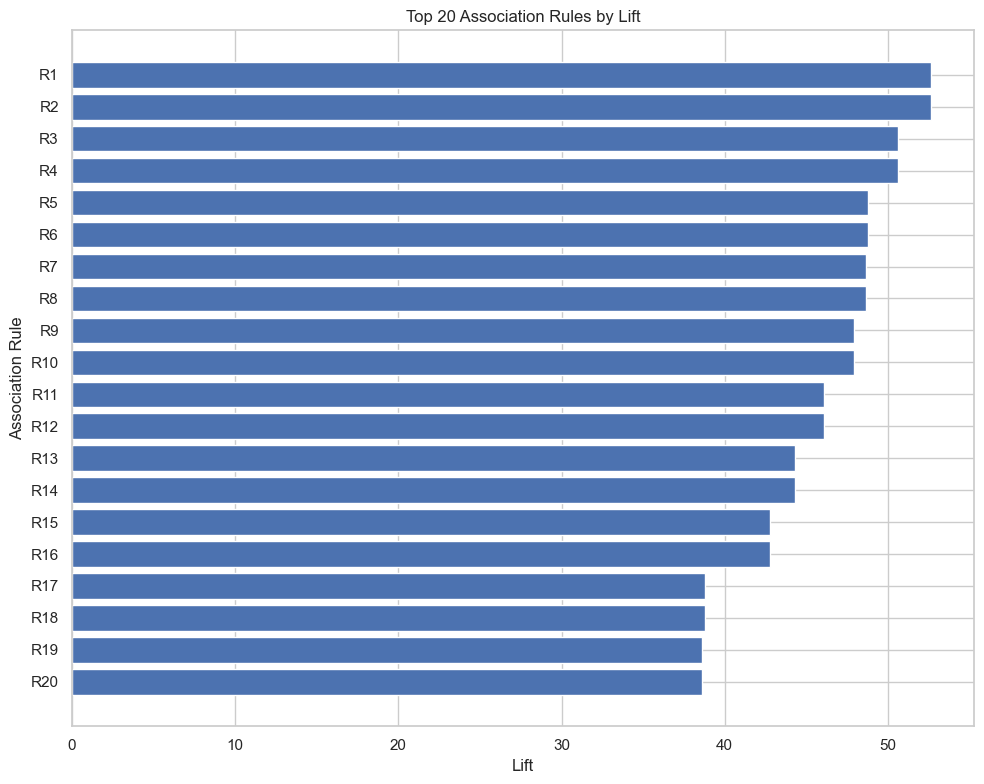

In [ ]:
# Tạo bản copy để vẽ bar chart
bar_rules = top20_rules.copy()

# Tạo nhãn ngắn cho rule để biểu đồ dễ đọc
bar_rules["rule_label"] = bar_rules["rule_id"].apply(
    lambda x: f"R{x}"
)

# Sắp xếp tăng dần để rule có lift cao nhất nằm trên cùng khi vẽ barh
bar_rules = bar_rules.sort_values(
    by="lift",
    ascending=True
)

# Tạo figure
plt.figure(figsize=(10, 8))

# Vẽ bar chart ngang
plt.barh(
    bar_rules["rule_label"],
    bar_rules["lift"]
)

# Đặt tên trục X
plt.xlabel("Lift")

# Đặt tên trục Y
plt.ylabel("Association Rule")

# Đặt tiêu đề
plt.title("Top 20 Association Rules by Lift")

# Tối ưu bố cục
plt.tight_layout()

# Lưu hình
plt.savefig(
    "bar_top20_rules_by_lift.png",
    dpi=300,
    bbox_inches="tight"
)

# Hiển thị biểu đồ
plt.show()

In [ ]:
# Bảng đối chiếu rule_id với rule và lift
top20_rules[
    ["rule_id", "rule", "support", "confidence", "lift"]
]

,rule_id,rule,support,confidence,lift
0,1,"22748, 22745 → 22746",0.010433,0.741107,52.646405
1,2,"22746 → 22748, 22745",0.010433,0.741107,52.646405
2,3,"22748, 22746 → 22745",0.010433,0.870070,50.606233
3,4,"22745 → 22748, 22746",0.010433,0.606796,50.606233
4,5,22300 → 22301,0.010015,0.762712,48.782345
5,6,22301 → 22300,0.010015,0.640569,48.782345
6,7,"22746, 22745 → 22748",0.010433,0.899281,48.681687
7,8,"22748 → 22746, 22745",0.010433,0.564759,48.681687
8,9,22746 → 22745,0.011601,0.824111,47.933104
9,10,22745 → 22746,0.011601,0.674757,47.933104
